# S3-4 シナリオ分析とストレステスト

## 学習目標

- パラレル・スティープ・フラット・バタフライという4つのカーブ変動類型を、
  数式とゼロレートの形で定義できる
- カーブ変動の主成分分析（PCA）を共分散行列の固有値分解から自分で導出し、
  第1〜第3主成分がレベル・スロープ・曲率に対応する理由を説明できる
- 主成分の符号と回転の任意性、レート差分と対数差分の選択、ヒストリカル
  シナリオの選定基準という「実務で迷う論点」に判断基準を持てる
- 主成分からストレスシナリオを生成し、仮想ポートフォリオを再評価して
  シナリオ損益とワースト損失を報告できる

S3-1〜3-3 で1本の債券・カーブに対する感応度（デュレーション・DV01・KRD）を
扱った。本編はそれを**カーブ全体が確率的に動く**世界へ拡張し、
「どの方向にどれだけ動きうるか」をデータから抽出してポートフォリオに当てる。

## 実務での位置づけ（ファンドはどう稼ぐか）

シナリオ分析・PCA・ストレステストは、個別債券の感応度（デュレーション・DV01・KRD）を「カーブ全体がどう動きうるか」という確率的な世界へ引き上げる道具です。使い手の中心はリスク管理クオンツで、ポートフォリオを仮想的なカーブ変動に晒し、シナリオ損益とワースト損失を日次で経営とデスクに報告します。マクロやレラティブバリューのファンドも、ポジションを取る前に「この本は歴史的に見てどの方向のカーブ変動に一番弱いか」を確認するために使います。パラレル・スティープ・フラット・バタフライという4類型は現場の共通言語で、PCAはそれらがデータからレベル・スロープ・曲率という3つの主成分として復元されることを示します。

収益とリスク管理への繋がりは、少数の主成分でリスクを束ねられる点にあります。カーブは数十本のテナーで動きますが、その分散の大半は上位3因子で説明できるため、ポジションのリスクを「レベルにいくら、スロープにいくら、曲率にいくら」という扱いやすい形に圧縮できます。これにより、意図した因子（例えばスティープ化への賭け）だけを残し、他の因子を消すヘッジ設計ができます。ストレステストは通常のVaRが捉えにくい極端な変動——過去の金融危機並みのスティープ化や、想定外のバタフライ——を当てて、リミット内に収まっているつもりのポジションが最悪シナリオでいくら失うかを事前に見積もります。ここで損失が許容を超えれば、ポジションを落とすかヘッジを厚くする判断につながります。

具体的な場面として、主成分の符号と回転には任意性があり、レート差分と対数差分のどちらを使うか、どのヒストリカルシナリオを採用するかで結果が変わります。これらの実務論点に一貫した判断基準を持てないと、シナリオ損益の数字が恣意的になり、リスク報告そのものの信頼性が失われます。カーブのストレスシナリオを自分で生成し仮想ポートフォリオを再評価できないことは、非平行シフトに対するリスクを定量化できないことを意味し、マクロデスクのポジション管理も規制対応のストレステストも成り立ちません。


## 理論

### カーブ変動の4類型

ゼロレート曲線を $z(\tau)$（$\tau$ はテナー年数）とする。日々の変化
$\Delta z(\tau)$ は、実務では次の少数の「型」の重ね合わせとして語られる。

| 類型 | 日本語 | 形 | 代表的な $\Delta z(\tau)$ |
|---|---|---|---|
| parallel | パラレルシフト | 全テナーが同量動く | $\Delta z(\tau) = a$ |
| steepening | スティープ化 | 長短スプレッド拡大 | $\Delta z(\tau) = b\,(\tau-\bar\tau)$、$b>0$ |
| flattening | フラット化 | 長短スプレッド縮小 | $\Delta z(\tau) = b\,(\tau-\bar\tau)$、$b<0$ |
| butterfly | バタフライ | 中期と両端が逆方向 | $\Delta z(\tau) = c\,\big((\tau-\bar\tau)^2 - k\big)$ |

スティープ化とフラット化は符号が違うだけの同一因子で、短期を軸に長期が
上下する。バタフライは「両翼（wings）と胴体（belly）」が逆に動く曲率変化で、
中期を持ち両端を売る／その逆のトレードが対応する。

これらは天下り的な分類に見えるが、後述の PCA が**データから**ほぼ同じ3つの
型（レベル＝パラレル、スロープ＝スティープ／フラット、曲率＝バタフライ）を
復元する。ここが本編の要である。

### 主成分分析（PCA）を固有値分解から導く

$T$ 日 × $n$ テナーのゼロレート変化行列を $X$（行が日、列がテナー）とする。
各列を中心化した $\tilde X = X - \bar X$ の標本共分散行列は

$$ \Sigma = \frac{1}{T-1}\,\tilde X^\top \tilde X \in \mathbb{R}^{n\times n}. $$

主成分分析は「テナー間で相関して動く $n$ 次元の変動を、互いに無相関な少数の
軸へ座標変換する」操作である。第1主成分の負荷ベクトル $w_1$（単位ベクトル）は、
その方向へ射影したときの分散を最大にする向きとして定義される。

$$ w_1 = \arg\max_{\|w\|=1}\ \operatorname{Var}(\tilde X w) = \arg\max_{\|w\|=1}\ w^\top \Sigma w. $$

制約付き最大化をラグランジュ未定乗数 $\lambda$ で解くと

$$ \nabla_w\big(w^\top\Sigma w - \lambda(w^\top w - 1)\big) = 0
   \ \Longrightarrow\ \Sigma w = \lambda w. $$

すなわち**負荷ベクトルは共分散行列の固有ベクトル**であり、そのときの分散は
$w^\top\Sigma w = \lambda$、つまり**固有値がその主成分の分散**になる。$\Sigma$ は
対称半正定値なので固有値は非負・実数で、固有ベクトルは直交する。よって固有値を
降順 $\lambda_1\ge\lambda_2\ge\cdots$ に並べれば、対応する固有ベクトルが第1・第2・
… 主成分となる。第 $i$ 主成分の**寄与率**（explained ratio）は

$$ \text{寄与率}_i = \frac{\lambda_i}{\sum_{j=1}^n \lambda_j}, \qquad
   \text{累積寄与率} = \frac{\sum_{i\le k}\lambda_i}{\sum_j \lambda_j}. $$

金利カーブでは経験的に、第1〜第3主成分で分散の**約95〜99%**が説明できる
（Litterman–Scheinkman 以来の定型的知見）。この3因子がレベル・スロープ・曲率
である。

### 主成分の符号と回転の任意性

固有ベクトル $w_i$ は $-w_i$ でも固有方程式を満たすため、**主成分の符号は
一意でない**。$w_1$ が全て正でも全て負でも「レベル」であることは変わらない。
実務では「レベルは正で上昇」「スロープは長期側を正」など符号規約を決めて固定する。
また固有値が縮退（ほぼ同値）する場合、その固有空間内で固有ベクトルは**回転の
自由度**を持ち、個々の軸の向きは不安定になる。カーブでは第1固有値が突出して
大きいためレベルは安定だが、寄与率が小さい高次成分の形は標本ごとに揺れやすい。

### レート差分と対数差分の選択

PCA にかける「変化」を、レート差分 $\Delta z_t = z_t - z_{t-1}$ にするか、
対数差分 $\Delta \ln z_t = \ln z_t - \ln z_{t-1}$ にするかは前提が違う。

| 変化の定義 | 暗黙の前提 | 向き・注意 |
|---|---|---|
| レート差分（bp 変化） | 変動の大きさがレート水準に依らない（正規的） | 金利では標準。低・ゼロ・負金利でも定義できる |
| 対数差分（相対変化） | 変動が水準に比例（対数正規的） | ボラが水準比例のとき妥当。ゼロ・負金利で発散し使えない |

株価は対数差分が定番だが、金利は水準がゼロや負を取りうるため、本編は
**レート差分（bp 単位の変化）**を用いる。これが債券リスク管理の標準である。

### ヒストリカルシナリオの選定基準

ストレステストのシナリオは大きく2種類ある。

- **ヒストリカルシナリオ**: 過去に実際に起きたカーブ変動（例: 2008年、2013年
  テーパータントラム、2020年3月）をそのまま当てる。整合性が担保され「実際に
  起きた」という説得力があるが、未経験の事象は捉えられない。
- **仮想シナリオ（PCA ベース）**: 主成分に沿って「$k$ シグマのレベル上昇」
  「$k$ シグマのスティープ化」等を人工的に作る。網羅的で強度を制御できるが、
  因子の独立性など前提に依存する。

ヒストリカルシナリオの選定基準は概ね次の通り。①損益方向にとって不利な向きか、
②十分な強度（過去分布のテールに位置するか）、③ポートフォリオの主要リスク
（デュレーション／曲率）を突く形か、④相互に独立で重複しないか。本編では PCA で
得た因子を使い、仮想シナリオとヒストリカル（実データの最悪日）の双方を評価する。

## スクラッチ実装

共分散の固有値分解による PCA を自作し、`bondlab.analytics.pca` と一致させる。
あわせて、主成分からシナリオを生成しポートフォリオを再評価するエンジンを組む。

### 使用する自作関数

| 関数 | 引数 | 返り値 | 役割 |
|---|---|---|---|
| `pca_scratch(changes)` | 変化行列（行=日, 列=テナー） | `dict(eigenvalues, eigenvectors, explained_ratio)` | 共分散を固有値分解して主成分を返す（`analytics.pca` の再実装） |
| `align_sign(V, ref)` | 負荷行列, 参照行列 | 符号を揃えた負荷行列 | 符号任意性を消して2実装を比較可能にする |
| `make_factor_changes(loads, sd, T, seed)` | 因子負荷, 因子SD, 日数, 乱数種 | 合成変化行列 | 既知の3因子から合成データを作り検証に使う |
| `zero_panel_from_par(par_panel, tenors, grid)` | パー利回りパネル, 報告テナー, 支払グリッド | ゼロレートパネル | 日次にパー→年次グリッド補間→ブートストラップ→報告テナーのゼロを読む |
| `present_value_on_curve(bond, curve, asof)` | 債券, 割引カーブ, 評価日 | 現在価値 | カーブの割引係数でキャッシュフローを割り引く |
| `shift_curve(tenors, base_zero, dz)` | テナー, 基準ゼロ, ゼロ変化 | 変化後 `DiscountCurve` | ゼロレートを bp シフトした新カーブを作る |
| `scenario_pnl(port, tenors, base_zero, dz, asof)` | ポートフォリオ, テナー, 基準ゼロ, シフト, 評価日 | シナリオ損益 | 全建玉を再評価し損益（変化後−基準）を合計する |

In [1]:
import numpy as np
import pandas as pd
import matplotlib

import matplotlib.pyplot as plt

plt.rcParams["font.family"] = ["Hiragino Sans", "Yu Gothic", "Meiryo", "IPAexGothic", "Noto Sans CJK JP", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
import bondlab
from bondlab import analytics
from bondlab import curve as blcurve
from bondlab.bond import FixedRateBond

SEED = 20260707
rng = np.random.default_rng(SEED)
print("bondlab version:", bondlab.__version__)


def pca_scratch(changes: np.ndarray) -> dict:
    """変化行列（行=日, 列=テナー）の主成分分析を固有値分解で行う。

    列ごとに中心化し、標本共分散行列 Σ を固有値分解する。固有値を降順に
    並べ替え、対応する固有ベクトル（列）と寄与率を返す。analytics.pca の
    独立実装であり、答え合わせに使う。
    """
    x = np.asarray(changes, dtype=float)
    x = x - x.mean(axis=0, keepdims=True)
    cov = np.cov(x, rowvar=False)          # rowvar=False: 列が変数（テナー）
    vals, vecs = np.linalg.eigh(cov)       # 対称行列用。固有値は昇順で返る
    order = np.argsort(vals)[::-1]         # 降順に並べ替え
    vals = vals[order]
    vecs = vecs[:, order]
    explained = vals / vals.sum()
    return dict(eigenvalues=vals, eigenvectors=vecs, explained_ratio=explained)


def align_sign(V: np.ndarray, ref: np.ndarray) -> np.ndarray:
    """負荷行列 V の各列（主成分）の符号を、参照 ref に揃える。

    固有ベクトルは符号任意なので、内積が負の列を反転して比較可能にする。
    """
    V = V.copy()
    for i in range(V.shape[1]):
        if np.dot(V[:, i], ref[:, i]) < 0:
            V[:, i] = -V[:, i]
    return V

bondlab version: 0.0.1


### 合成データによる検証：既知の3因子を復元できるか

レベル（平坦）・スロープ（右肩）・曲率（山型）の3つの負荷を人工的に置き、
それぞれ大きく異なる分散を与えて変化データを合成する。PCA が3因子で
ほぼ全分散を説明し（文献値の約95〜99%のオーダー）、負荷の形を復元することを
確認する。

In [2]:
tenors = np.array([0.5, 1.0, 2.0, 3.0, 5.0, 7.0, 10.0, 20.0, 30.0])
n = tenors.size

# 既知の3因子の負荷（正規直交ではないが、形として level/slope/curvature）。
level = np.ones(n)
slope = tenors - tenors.mean()
curv = (tenors - tenors.mean()) ** 2 - ((tenors - tenors.mean()) ** 2).mean()
loads_true = np.column_stack([
    level / np.linalg.norm(level),
    slope / np.linalg.norm(slope),
    curv / np.linalg.norm(curv),
])
factor_sd = np.array([8.0e-4, 3.0e-4, 1.0e-4])  # レベルが支配的、曲率は小さい


def make_factor_changes(loads: np.ndarray, sd: np.ndarray, T: int, seed) -> np.ndarray:
    """既知の因子負荷 loads と因子SD sd から、合成のカーブ変化行列を作る。

    各日について因子スコア（独立正規）を引き、負荷と線形結合してテナー別の
    変化を生成する。微小な観測ノイズも足す。検証用の「正解が分かるデータ」。
    """
    gen = np.random.default_rng(seed)
    scores = gen.normal(size=(T, sd.size)) * sd       # 日 × 因子
    changes = scores @ loads.T                          # 日 × テナー
    changes += gen.normal(scale=2e-5, size=changes.shape)  # 観測ノイズ
    return changes


synthetic = make_factor_changes(loads_true, factor_sd, T=250, seed=SEED)

res_scratch = pca_scratch(synthetic)
res_lib = analytics.pca(synthetic)

cum3 = res_scratch["explained_ratio"][:3].sum()
print("合成データの寄与率（上位5）:", np.round(res_scratch["explained_ratio"][:5], 4))
print(f"第1〜3主成分の累積寄与率     : {cum3:.4f}")
assert 0.95 <= cum3 <= 0.9999, "累積寄与率が文献値のオーダー(約95-99%)から外れた"
print("累積寄与率は文献値のオーダー（約95-99%）に収まる")

合成データの寄与率（上位5）: [8.560e-01 1.363e-01 4.400e-03 7.000e-04 6.000e-04]
第1〜3主成分の累積寄与率     : 0.9967
累積寄与率は文献値のオーダー（約95-99%）に収まる


### 自作 PCA == `analytics.pca` の一致確認

PCA には QuantLib の対応物が無い。よって本編の「検証」は、
**自作 `pca_scratch` と `bondlab.analytics.pca` の数値一致**と、
**合成データで累積寄与率が文献値（約95〜99%）のオーダーに入ること**の
二本立てで行う（次節の「QuantLib検証」参照）。固有ベクトルは符号任意なので、
符号を揃えてから比較する。

In [3]:
V_scratch = align_sign(res_scratch["eigenvectors"], res_lib["eigenvectors"])

assert np.allclose(res_scratch["eigenvalues"], res_lib["eigenvalues"], atol=1e-12)
assert np.allclose(res_scratch["explained_ratio"], res_lib["explained_ratio"], atol=1e-12)
assert np.allclose(V_scratch, res_lib["eigenvectors"], atol=1e-10)
print("固有値・寄与率・負荷ベクトル（符号調整後）が analytics.pca と一致")

# 復元した第1〜3主成分が、それぞれ level/slope/curv の形に対応することを
# コサイン類似度で確認する（レベルは定数ベクトルで相関が未定義になるため、
# 中心化しないコサイン |<a,b>|/(||a||·||b||) を使う）。
def cosine_sim(a, b):
    return abs(np.dot(a, b)) / (np.linalg.norm(a) * np.linalg.norm(b))


for k, name in zip(range(3), ["レベル", "スロープ", "曲率"]):
    sim = cosine_sim(V_scratch[:, k], loads_true[:, k])
    print(f"第{k + 1}主成分 vs 既知の{name}負荷 のコサイン類似度 = {sim:.3f}")

固有値・寄与率・負荷ベクトル（符号調整後）が analytics.pca と一致
第1主成分 vs 既知のレベル負荷 のコサイン類似度 = 1.000
第2主成分 vs 既知のスロープ負荷 のコサイン類似度 = 0.998
第3主成分 vs 既知の曲率負荷 のコサイン類似度 = 0.503


## QuantLib検証

**PCA は QuantLib に直接の対応物を持たない**ため、本編の検証は QuantLib 突合
ではなく次の2点で行う（前節で実施済み）。

1. **自作 `pca_scratch` == `bondlab.analytics.pca`**: 固有値・寄与率・（符号を
   揃えた）負荷ベクトルが数値的に一致することを `assert` で確認した。
2. **寄与率のオーダー整合**: 既知の3因子で作った合成データで、第1〜3主成分の
   累積寄与率が文献値の約95〜99%のオーダーに収まることを確認した。

ここでは検証の要点を1つの表に集約して残す。

In [4]:
check = pd.DataFrame({
    "検証項目": [
        "固有値 max|差|",
        "寄与率 max|差|",
        "負荷（符号調整後）max|差|",
        "累積寄与率(第1-3)",
        "文献オーダー(0.95-0.99)整合",
    ],
    "値": [
        f"{np.max(np.abs(res_scratch['eigenvalues'] - res_lib['eigenvalues'])):.2e}",
        f"{np.max(np.abs(res_scratch['explained_ratio'] - res_lib['explained_ratio'])):.2e}",
        f"{np.max(np.abs(V_scratch - res_lib['eigenvectors'])):.2e}",
        f"{cum3:.4f}",
        "OK" if 0.95 <= cum3 <= 0.9999 else "NG",
    ],
})
print(check.to_string(index=False))

               検証項目        値
         固有値 max|差| 0.00e+00
         寄与率 max|差| 0.00e+00
    負荷（符号調整後）max|差| 0.00e+00
        累積寄与率(第1-3)   0.9967
文献オーダー(0.95-0.99)整合       OK


## 実データ適用

合成パー利回りパネル `data/samples/synthetic_ust_par_panel.csv`（60営業日 × 9
テナー）を読み、日次にゼロレート曲線を構築する。ゼロレート変化の PCA から
レベル・スロープ・曲率を取り出し、それを仮想ポートフォリオに当ててシナリオ
損益を評価する。ネットワークには一切アクセスしない。

In [5]:
panel = pd.read_csv("data/samples/synthetic_ust_par_panel.csv")
par_wide = panel.pivot(index="date", columns="tenor", values="par_yield").sort_index()
report_tenors = par_wide.columns.to_numpy(dtype=float)
print("パネル形状 (日 × テナー):", par_wide.shape)
print("テナー:", report_tenors)
print(par_wide.iloc[:3].round(5))

パネル形状 (日 × テナー): (60, 9)
テナー: [ 0.5  1.   2.   3.   5.   7.  10.  20.  30. ]
tenor          0.5      1.0      2.0      3.0      5.0      7.0      10.0  \
date                                                                        
2026-01-02  0.02818  0.03082  0.03481  0.03757  0.04080  0.04241  0.04350   
2026-01-05  0.02817  0.03081  0.03480  0.03755  0.04079  0.04239  0.04347   
2026-01-06  0.02815  0.03079  0.03478  0.03753  0.04076  0.04235  0.04343   

tenor          20.0     30.0  
date                          
2026-01-02  0.04438  0.04460  
2026-01-05  0.04433  0.04453  
2026-01-06  0.04426  0.04443  


### 日次カーブの構築とゼロレートパネル

各営業日について、9テナーのパー利回りを年次の支払グリッド（1〜30年）へ
線形補間し、`bootstrap_par(..., frequency=1)` で割引カーブを剥ぎ取る。
こうして得た連続複利ゼロレートを、報告テナーの位置で読み出してパネル化する。

補足: `bootstrap_par` は「テナー＝クーポン支払日で等間隔」を前提とする。生の
9テナー（0.5, 1, 2, 3, 5, 7, 10, 20, 30）は等間隔でないため、いったん等間隔の
年次グリッドへ補間してから剥ぎ取るのが素直で、前提とも整合する。

In [6]:
payment_grid = np.arange(1.0, 31.0)  # 等間隔（1年刻み）の年次支払グリッド


def zero_panel_from_par(par_panel: pd.DataFrame, tenors: np.ndarray, grid: np.ndarray) -> np.ndarray:
    """パー利回りパネルから、各日のゼロレートを報告テナー位置で読んだ行列を返す。

    日ごとに: パー利回りを年次グリッドへ線形補間 → bootstrap_par で割引カーブ
    → 報告テナーの連続複利ゼロレートを読む。行=日, 列=報告テナー。
    """
    rows = []
    for _date, par_row in par_panel.iterrows():
        par_on_grid = np.interp(grid, tenors, par_row.to_numpy(dtype=float))
        crv = blcurve.bootstrap_par(grid, par_on_grid, frequency=1)
        rows.append(crv.zero_rate(tenors))
    return np.asarray(rows)


zero_panel = zero_panel_from_par(par_wide, report_tenors, payment_grid)
dz = np.diff(zero_panel, axis=0)  # 日次のゼロレート差分（レート差分を採用）
print("ゼロレートパネル形状:", zero_panel.shape, " 変化行列形状:", dz.shape)
print("平均ゼロレート(%):", np.round(zero_panel.mean(axis=0) * 100, 3))

ゼロレートパネル形状: (60, 9)  変化行列形状: (59, 9)
平均ゼロレート(%): [2.989 2.989 3.382 3.656 3.982 4.144 4.253 4.332 4.339]


### ゼロレート変化の PCA と因子の同定

変化行列 `dz` に自作 PCA を当て、`analytics.pca` と一致することを確認しつつ、
第1〜3主成分をレベル（パラレル）・スロープ（スティープ／フラット）・
曲率（バタフライ）へ対応づける。符号規約は「第1主成分の平均負荷を正」に固定する。

In [7]:
pca_real = pca_scratch(dz)
pca_real_lib = analytics.pca(dz)
assert np.allclose(pca_real["eigenvalues"], pca_real_lib["eigenvalues"], atol=1e-12)

loads = pca_real["eigenvectors"][:, :3].copy()
# 符号規約: PC1 は平均を正、PC2 は長期端(最終テナー)を正、PC3 は中央(belly)を正。
if loads[:, 0].mean() < 0:
    loads[:, 0] = -loads[:, 0]
if loads[-1, 1] < 0:
    loads[:, 1] = -loads[:, 1]
belly = n // 2
if loads[belly, 2] < 0:
    loads[:, 2] = -loads[:, 2]

cum3_real = pca_real["explained_ratio"][:3].sum()
print("実データの寄与率（上位5）:", np.round(pca_real["explained_ratio"][:5], 4))
print(f"第1〜3主成分の累積寄与率 : {cum3_real:.4f}")

factor_table = pd.DataFrame(loads, index=report_tenors, columns=["PC1", "PC2", "PC3"])
factor_table.index.name = "テナー"
print("\n主成分の負荷ベクトル:")
print(factor_table.round(3).to_string())

# 因子の同定: PC1=ほぼ同符号(レベル), PC2=単調符号反転(スロープ), PC3=山谷(曲率)。
pc1_same_sign = np.all(np.sign(loads[:, 0]) == np.sign(loads[0, 0]))
pc2_monotone_ish = loads[0, 1] * loads[-1, 1] < 0  # 両端で符号が反転
print(f"\nPC1 は全テナー同符号か（レベル=パラレルの証拠）: {pc1_same_sign}")
print(f"PC2 は両端で符号反転か（スロープ=スティープ/フラットの証拠）: {pc2_monotone_ish}")

実データの寄与率（上位5）: [9.09e-01 8.90e-02 6.00e-04 5.00e-04 3.00e-04]
第1〜3主成分の累積寄与率 : 0.9986

主成分の負荷ベクトル:
        PC1    PC2    PC3
テナー                      
0.5   0.319 -0.267  0.165
1.0   0.319 -0.267  0.165
2.0   0.320 -0.245 -0.032
3.0   0.322 -0.224 -0.339
5.0   0.322 -0.159  0.359
7.0   0.329 -0.109 -0.133
10.0  0.332 -0.012 -0.562
20.0  0.356  0.338  0.573
30.0  0.377  0.772 -0.198

PC1 は全テナー同符号か（レベル=パラレルの証拠）: True
PC2 は両端で符号反転か（スロープ=スティープ/フラットの証拠）: True


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


...

findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


負荷ベクトルの図を生成しました（PC1=レベル, PC2=スロープ, PC3=曲率）


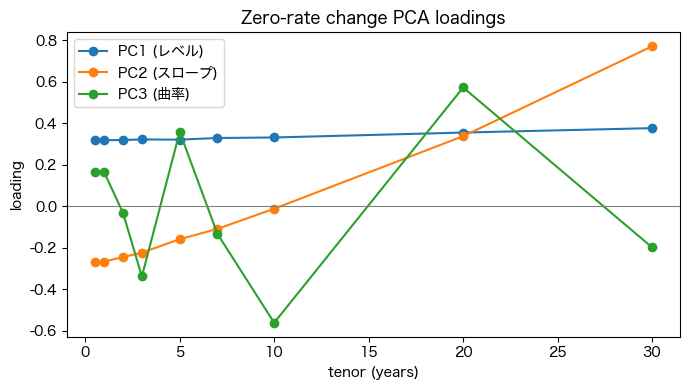

In [8]:
# 負荷ベクトルの可視化（演習1の下地）。
fig, ax = plt.subplots(figsize=(7, 4))
for k, (name, jp) in enumerate(zip(["PC1", "PC2", "PC3"], ["レベル", "スロープ", "曲率"])):
    ax.plot(report_tenors, loads[:, k], marker="o", label=f"{name} ({jp})")
ax.axhline(0.0, color="gray", lw=0.8)
ax.set_xlabel("tenor (years)")
ax.set_ylabel("loading")
ax.set_title("Zero-rate change PCA loadings")
ax.legend()
fig.tight_layout()
print("負荷ベクトルの図を生成しました（PC1=レベル, PC2=スロープ, PC3=曲率）")

### ポートフォリオ再評価エンジン

仮想の固定利付債ポートフォリオを組み、割引カーブでキャッシュフローを割り引く
再評価関数を用意する。シナリオはゼロレートへの bp シフトとして与え、シフト後
カーブで再評価した価値と基準価値の差をシナリオ損益とする。

In [9]:
import datetime as dt

asof = dt.date(2026, 3, 31)  # 評価日（パネル期間内）

# ベースのゼロレート（最終営業日のカーブ）を基準に使う。
base_zero = zero_panel[-1]


def present_value_on_curve(bond: FixedRateBond, curve: blcurve.DiscountCurve, asof: dt.date) -> float:
    """割引カーブでキャッシュフローを割り引いた債券の現在価値（dirty PV）。

    評価日より後の各キャッシュフロー (日付, 額) を、経過年数 t=(日付-評価日)/365
    の割引係数で割り引いて合計する。YTM ではなくカーブで評価する点が要。
    """
    pv = 0.0
    for d, c in bond.cashflows():
        if d > asof:
            t = (d - asof).days / 365.0
            pv += c * curve.discount(t)
    return pv


def shift_curve(tenors: np.ndarray, base_zero: np.ndarray, dz_shift: np.ndarray) -> blcurve.DiscountCurve:
    """ゼロレートを dz_shift だけ動かした割引カーブを構築する。

    連続複利ゼロ z(τ) を用いて DF(τ)=exp(-(z+Δz)·τ) とし、DiscountCurve を作る。
    """
    z = base_zero + dz_shift
    dfs = np.exp(-z * tenors)
    return blcurve.DiscountCurve(tenors, dfs, interp="linear_zero")


def scenario_pnl(port, tenors, base_zero, dz_shift, asof) -> float:
    """ポートフォリオ port=[(bond, notional_weight), ...] のシナリオ損益。

    基準カーブとシフト後カーブでそれぞれ再評価し、(変化後 − 基準) を額面
    ウエイトで加重合計する。正が利益。
    """
    base_curve = shift_curve(tenors, base_zero, np.zeros_like(base_zero))
    scen_curve = shift_curve(tenors, base_zero, dz_shift)
    pnl = 0.0
    for bond, w in port:
        p0 = present_value_on_curve(bond, base_curve, asof)
        p1 = present_value_on_curve(bond, scen_curve, asof)
        pnl += w * (p1 - p0)
    return pnl


# 仮想ポートフォリオ: 短期・中期・長期の固定利付債を保有（額面ウエイト）。
portfolio = [
    (FixedRateBond(dt.date(2025, 3, 31), dt.date(2028, 3, 31), 0.030, frequency=2), 40.0),   # 2年
    (FixedRateBond(dt.date(2025, 3, 31), dt.date(2033, 3, 31), 0.038, frequency=2), 35.0),   # 7年
    (FixedRateBond(dt.date(2025, 3, 31), dt.date(2046, 3, 31), 0.044, frequency=2), 25.0),   # 20年
]
base_curve = shift_curve(report_tenors, base_zero, np.zeros_like(base_zero))
base_value = sum(w * present_value_on_curve(b, base_curve, asof) for b, w in portfolio)
print(f"ポートフォリオ基準価値: {base_value:,.2f}")

ポートフォリオ基準価値: 9,913.48


### 主成分シナリオと損益

各主成分について「$\pm k$ シグマ」のシフトを作る。シフト量は
$\Delta z = k\sqrt{\lambda_i}\,w_i$（$\lambda_i$ は日次分散、$w_i$ は負荷）で、
1日変動の $k$ 倍スケール。ここでは1日 $\pm2\sigma$ を用いる。あわせて、実データ
期間で**実際に起きた最悪日**（ヒストリカルシナリオ）の損益も評価する。

In [10]:
k_sigma = 2.0
eig = pca_real["eigenvalues"]

scenarios = {}
for i, name in zip(range(3), ["PC1 レベル(パラレル)", "PC2 スロープ(スティープ)", "PC3 曲率(バタフライ)"]):
    amp = k_sigma * np.sqrt(eig[i]) * loads[:, i]
    scenarios[f"+2σ {name}"] = amp
    scenarios[f"-2σ {name}"] = -amp

# 仮想の手組みシナリオも追加（bp 指定）。
scenarios["手組: パラレル +100bp"] = np.full(n, 0.0100)
scenarios["手組: スティープ (短-50/長+50bp)"] = np.linspace(-0.0050, 0.0050, n)
scenarios["手組: バタフライ (翼+25/胴-25bp)"] = 0.0025 * (loads[:, 2] / np.max(np.abs(loads[:, 2])))

pnl_rows = []
for name, shift in scenarios.items():
    pnl_rows.append((name, scenario_pnl(portfolio, report_tenors, base_zero, shift, asof)))

# ヒストリカルシナリオ: 実データの各日変化をそのまま当て、最悪日を探す。
hist_pnls = np.array([
    scenario_pnl(portfolio, report_tenors, base_zero, dz[t], asof) for t in range(dz.shape[0])
])
worst_day = int(np.argmin(hist_pnls))
pnl_rows.append((f"ヒストリカル最悪日 (#{worst_day})", hist_pnls[worst_day]))

pnl_df = pd.DataFrame(pnl_rows, columns=["シナリオ", "損益"]).sort_values("損益")
pnl_df["損益(bp of PV)"] = pnl_df["損益"] / base_value * 1e4
print(pnl_df.round(4).to_string(index=False))
print(f"\nワースト損失: {pnl_df['損益'].min():,.4f}  （シナリオ: {pnl_df.iloc[0]['シナリオ']}）")

                   シナリオ        損益  損益(bp of PV)
        手組: パラレル +100bp -594.3940     -599.5819
手組: スティープ (短-50/長+50bp) -107.9801     -108.9225
手組: バタフライ (翼+25/胴-25bp)  -38.6827      -39.0203
      +2σ PC1 レベル(パラレル)  -10.8112      -10.9056
        ヒストリカル最悪日 (#28)   -9.1765       -9.2566
    +2σ PC2 スロープ(スティープ)   -0.5959       -0.6011
      +2σ PC3 曲率(バタフライ)   -0.1169       -0.1179
      -2σ PC3 曲率(バタフライ)    0.1169        0.1179
    -2σ PC2 スロープ(スティープ)    0.5974        0.6026
      -2σ PC1 レベル(パラレル)   10.8342       10.9287



ワースト損失: -594.3940  （シナリオ: 手組: パラレル +100bp）


パラレル上昇（レベル因子の $+$ 側）が最大の損失を生むことが読み取れる。これは
ポートフォリオが正のデュレーションを持つ（金利上昇＝価格下落）ためで、S3-1 の
デュレーションの符号と整合する。曲率シナリオの損益が小さいのは、寄与率が
示すとおり曲率因子の変動が小さいことの反映である。

## 演習

1. 実データの第1〜3主成分の負荷ベクトルを1枚の図に重ね描きし、それぞれが
   レベル・スロープ・曲率のどれに当たるかを、負荷の符号と単調性から説明せよ。
   「PC2 の両端の符号が逆」「PC3 が中期で山（谷）」といった観察を根拠に述べること。
2. パラレル・スティープ・フラット・バタフライを含むいくつかの仮想シフト
   （強度も複数）を与え、それぞれの仮想ポートフォリオ損益を計算して**ワースト
   損失**とそのシナリオを報告せよ。ワーストがどの因子で起きるかを、
   ポートフォリオのデュレーション構成から解釈せよ。

解答例は `solutions/S3/sol_0304.py` に置く。

## 用語集

定義の正は `glossary/03_risk.md`。ここでは初出語の一行要約のみ示す。

| 用語 | 英語 | 一行定義 |
|---|---|---|
| 主成分分析 | principal component analysis | 相関する多変量の変動を、無相関な少数の軸へ座標変換する手法。共分散の固有値分解で得る |
| 固有値 | eigenvalue | $\Sigma w=\lambda w$ の $\lambda$。その主成分が説明する分散に等しい |
| ストレステスト | stress test | 極端なシナリオ下でポートフォリオ損益・耐性を評価する手法 |
| シナリオ損益 | scenario P&L | あるシナリオ（カーブシフト等）で再評価した価値と基準価値の差 |
| 寄与率 | explained variance ratio | 全分散に対する各主成分の分散の割合。累積で説明力を測る |